# 🎓 SDG 4 — Quality Education Dashboard Analysis
### Understanding the Drivers of Average Years of Schooling Across Countries

---

| | |
|---|---|
| **Student** | Sheikha Maris Nicolas |
| **Section** | BSIS 3B |
| **Course** | Data Mining / Analytics |
| **SDG Focus** | SDG 4 — Quality Education |
| **Dataset** | 191 Countries · 2000–2023 |
| **Sources** | Our World in Data · World Bank · ILO · UNESCO |

---

## Research Question

> *What socioeconomic factors significantly influence the average years of schooling among adults across countries from 2000 to 2023?*

## Variables

| Role | Variable | Description | Literature |
|---|---|---|---|
| **Response (Y)** | `avg_years_schooling` | Average years of schooling among adults | Barro & Lee (2013) |
| **Explanatory (X₁)** | `log_gdp_per_capita` | Log of GDP per capita (USD) | Hanushek & Woessmann (2007) |
| **Explanatory (X₂)** | `gov_edu_spending_pct` | Gov. education spending (% of total) | UNESCO (2020) |
| **Explanatory (X₃)** | `female_male_labor_ratio` | Female to male labor force ratio | Duflo (2012) |
| **Explanatory (X₄)** | `internet_usage_pct` | Share of population using internet | Beuermann et al. (2015) |


## 1. Load Libraries and Dataset

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = '#1a1545'
plt.rcParams['axes.facecolor'] = '#2a2568'
plt.rcParams['text.color'] = '#E8D5A3'
plt.rcParams['axes.labelcolor'] = '#E8D5A3'
plt.rcParams['xtick.color'] = '#C9B8E8'
plt.rcParams['ytick.color'] = '#C9B8E8'
plt.rcParams['axes.titlecolor'] = '#F7B801'

print('✅ Libraries loaded successfully!')
print('Student: Sheikha Maris Nicolas | BSIS 3B')

✅ Libraries loaded successfully!
Student: Sheikha Maris Nicolas | BSIS 3B


In [14]:
# ── Load dataset
df = pd.read_csv('data/sdg4_cleaned.csv')
df['log_gdp_per_capita'] = np.log(df['gdp_per_capita'])

print(f'Shape: {df.shape}')
print(f'Countries: {df["Entity"].nunique()}')
print(f'Years: {df["Year"].min()} – {df["Year"].max()}')
print(f'\nColumns: {list(df.columns)}')
df.head(10)

Shape: (4490, 9)
Countries: 191
Years: 2000 – 2023

Columns: ['Entity', 'Code', 'Year', 'avg_years_schooling', 'gdp_per_capita', 'gov_edu_spending_pct', 'female_male_labor_ratio', 'internet_usage_pct', 'log_gdp_per_capita']


,Entity,Code,Year,avg_years_schooling,gdp_per_capita,gov_edu_spending_pct,female_male_labor_ratio,internet_usage_pct,log_gdp_per_capita
0,Afghanistan,AFG,2000,1.264052,1617.8264,14.559212,17.880240,0.004723,7.388839
1,Afghanistan,AFG,2001,1.315551,1454.1108,14.559212,17.765875,0.004723,7.282150
2,Afghanistan,AFG,2002,1.367049,1774.3087,14.559212,17.726784,0.004561,7.481166
3,Afghanistan,AFG,2003,1.418548,1815.9282,14.559212,17.750856,0.087891,7.504352
4,Afghanistan,AFG,2004,1.470046,1776.9182,14.559212,17.840546,0.105809,7.482636
5,Afghanistan,AFG,2005,1.521544,1908.1147,14.559212,17.991068,1.224150,7.553871
6,Afghanistan,AFG,2006,1.595281,1929.7239,14.559212,18.212980,2.107120,7.565132
7,Afghanistan,AFG,2007,1.669017,2155.3530,10.814692,18.529043,1.900000,7.675710
8,Afghanistan,AFG,2008,1.742754,2191.5044,4.860586,18.926758,1.840000,7.692344
9,Afghanistan,AFG,2009,1.816490,2565.0220,6.492490,19.371395,3.550000,7.849722


## 2. Data Exploration

In [15]:
# ── Dataset info
print('=== DATASET INFO ===')
df.info()
print('\n=== MISSING VALUES ===')
print(df.isnull().sum())

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4490 entries, 0 to 4489
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Entity                   4490 non-null   object 
 1   Code                     4490 non-null   object 
 2   Year                     4490 non-null   int64  
 3   avg_years_schooling      4490 non-null   float64
 4   gdp_per_capita           4490 non-null   float64
 5   gov_edu_spending_pct     4490 non-null   float64
 6   female_male_labor_ratio  4490 non-null   float64
 7   internet_usage_pct       4490 non-null   float64
 8   log_gdp_per_capita       4490 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 315.8+ KB

=== MISSING VALUES ===
Entity                     0
Code                       0
Year                       0
avg_years_schooling        0
gdp_per_capita             0
gov_edu_spending_pct       0
female_male_labor

In [16]:
# ── Descriptive statistics
desc_cols = ['avg_years_schooling','gdp_per_capita','gov_edu_spending_pct',
             'female_male_labor_ratio','internet_usage_pct']
df[desc_cols].describe().round(2)

,avg_years_schooling,gdp_per_capita,gov_edu_spending_pct,female_male_labor_ratio,internet_usage_pct
count,4490.00,4490.00,4490.00,4490.00,4490.00
mean,8.33,22038.11,14.19,70.62,38.34
std,3.25,23444.33,4.89,19.30,31.57
min,0.98,711.98,0.01,7.34,0.00
25%,5.79,5102.82,10.73,61.60,7.79
50%,8.68,13511.74,13.59,76.17,31.56
75%,11.02,30952.52,17.34,84.02,67.49
max,14.30,145590.77,35.01,106.24,100.00


## 3. Data Cleaning Summary

The dataset was cleaned through the following steps before loading:

1. **Year Filtering** — Restricted to 2000–2023 for maximum data overlap across all sources
2. **Country Filtering** — Removed regional/income aggregates; kept only sovereign countries with valid ISO-3 codes
3. **Missing Value Treatment:**
   - *Linear interpolation per country* — for countries with partial data, gaps filled by interpolating between known values
   - *Global year-median imputation* — for countries missing an entire variable, global median for that year used (standard in panel data analysis)
4. **Variable Exclusions** — `literacy_rate` (84% missing) and `poverty_headcount_pct` (72% missing) excluded due to excessive sparsity
5. **Log Transformation** — `gdp_per_capita` is right-skewed; log-transformed to `log_gdp_per_capita` for regression
6. **Final Dataset** — 4,490 rows × 191 countries × 24 years, zero missing values


## 4. Exploratory Data Analysis (EDA)

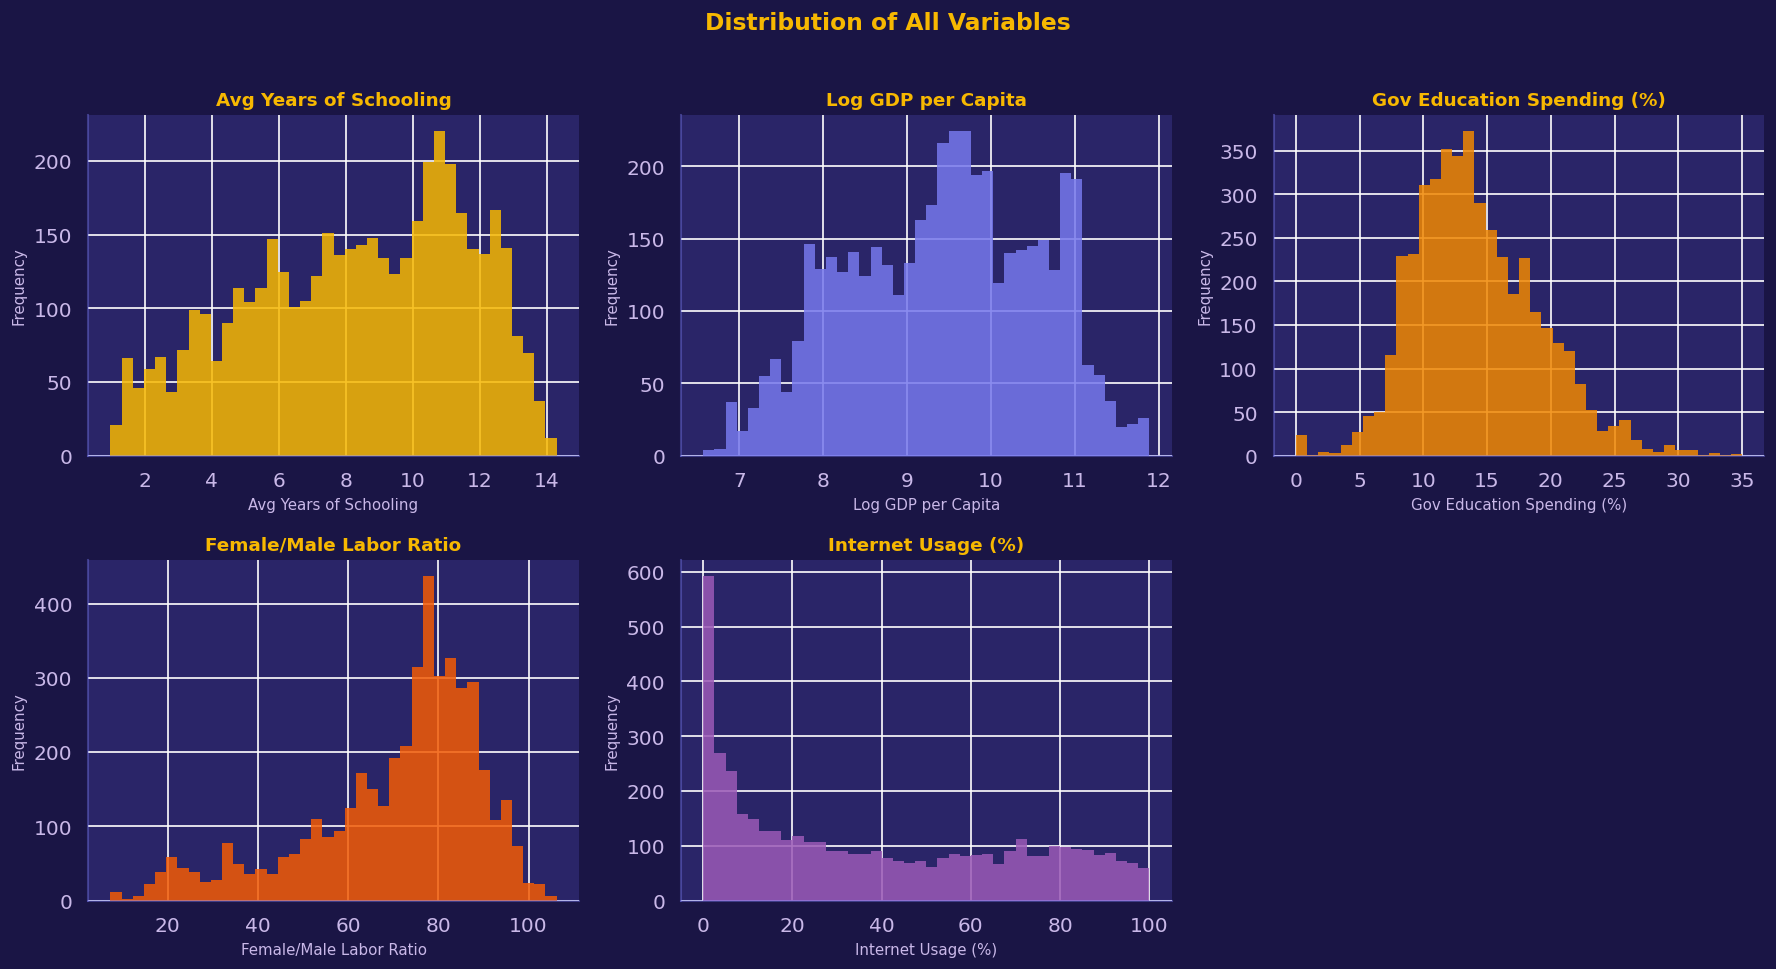

📌 GDP per capita is heavily right-skewed — log transformation applied.


In [17]:
# ── Distribution of all variables
C3, C2, C4, C5 = '#F7B801', '#7678ED', '#F18701', '#F35B04'
colors = [C3, C2, C4, C5, '#9B59B6']

vars_to_plot = [
    ('avg_years_schooling',    'Avg Years of Schooling'),
    ('log_gdp_per_capita',     'Log GDP per Capita'),
    ('gov_edu_spending_pct',   'Gov Education Spending (%)'),
    ('female_male_labor_ratio','Female/Male Labor Ratio'),
    ('internet_usage_pct',     'Internet Usage (%)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), facecolor='#1a1545')
axes = axes.flatten()
for i, (col, label) in enumerate(vars_to_plot):
    axes[i].hist(df[col].dropna(), bins=40, color=colors[i], edgecolor='none', alpha=0.85)
    axes[i].set_title(label, fontweight='bold', color='#F7B801', fontsize=11)
    axes[i].set_xlabel(label, color='#C9B8E8', fontsize=9)
    axes[i].set_ylabel('Frequency', color='#C9B8E8', fontsize=9)
    axes[i].set_facecolor('#2a2568')
    # Fix: Convert RGBA string to a tuple of floats for matplotlib
    axes[i].spines['bottom'].set_color((118/255, 120/255, 237/255, 0.4))
    axes[i].spines['left'].set_color((118/255, 120/255, 237/255, 0.4))
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

axes[5].set_visible(False)
fig.patch.set_facecolor('#1a1545')
plt.suptitle('Distribution of All Variables', fontsize=14, fontweight='bold',
             color='#F7B801', y=1.01)
plt.tight_layout()
plt.show()
print('📌 GDP per capita is heavily right-skewed — log transformation applied.')

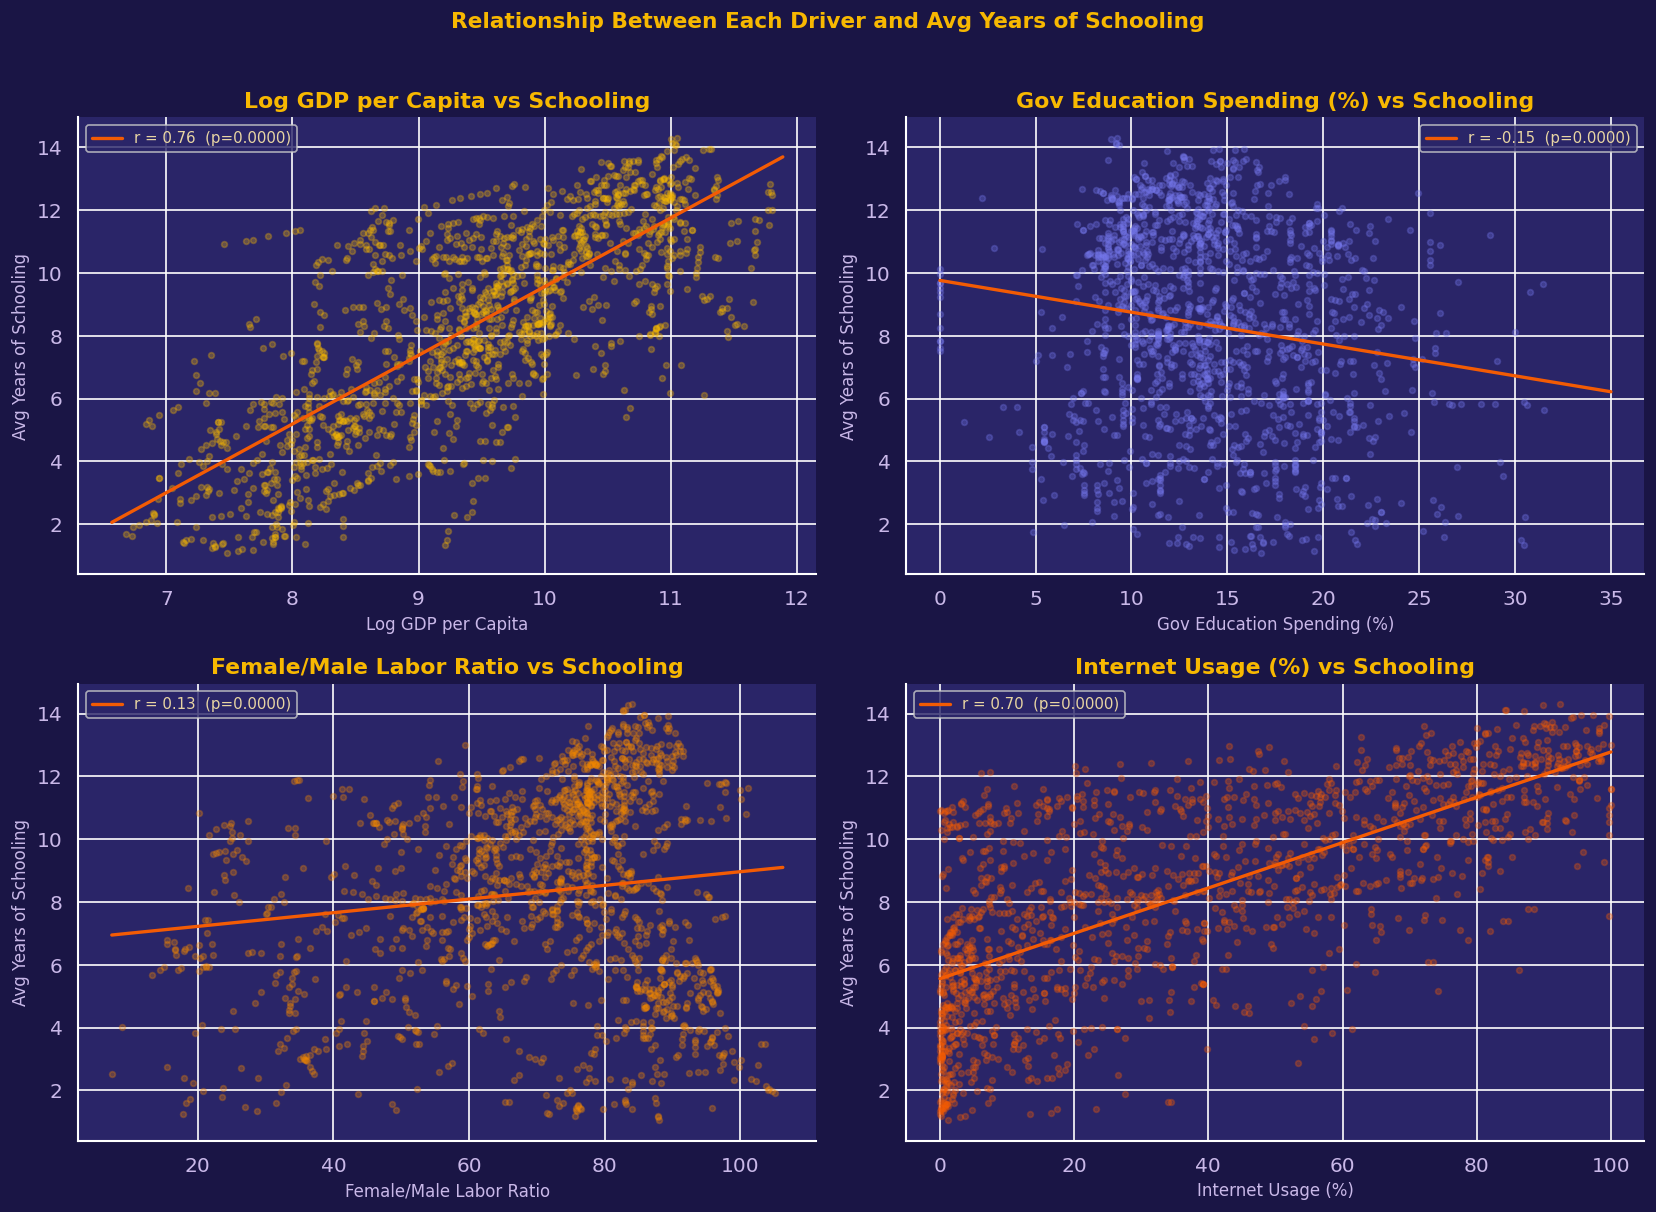

In [18]:
# ── Scatter plots: each X vs Y
x_vars = [
    ('log_gdp_per_capita',     'Log GDP per Capita'),
    ('gov_edu_spending_pct',   'Gov Education Spending (%)'),
    ('female_male_labor_ratio','Female/Male Labor Ratio'),
    ('internet_usage_pct',     'Internet Usage (%)'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='#1a1545')
axes = axes.flatten()
for i, (col, label) in enumerate(x_vars):
    sample = df.sample(min(1500,len(df)), random_state=42)
    axes[i].scatter(sample[col], sample['avg_years_schooling'],
                    alpha=0.3, s=12, color=colors[i])
    m, b, r, p, _ = stats.linregress(df[col].dropna(),
                    df.loc[df[col].notna(), 'avg_years_schooling'])
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m*x_line + b, color='#F35B04', linewidth=2,
                 label=f'r = {r:.2f}  (p={p:.4f})')
    axes[i].set_xlabel(label, color='#C9B8E8', fontsize=10)
    axes[i].set_ylabel('Avg Years of Schooling', color='#C9B8E8', fontsize=10)
    axes[i].set_title(f'{label} vs Schooling', fontweight='bold', color='#F7B801')
    axes[i].legend(fontsize=9, facecolor='#2a2568', labelcolor='#E8D5A3')
    axes[i].set_facecolor('#2a2568')
    for sp in ['top','right']: axes[i].spines[sp].set_visible(False)

fig.patch.set_facecolor('#1a1545')
plt.suptitle('Relationship Between Each Driver and Avg Years of Schooling',
             fontsize=13, fontweight='bold', color='#F7B801', y=1.01)
plt.tight_layout()
plt.show()

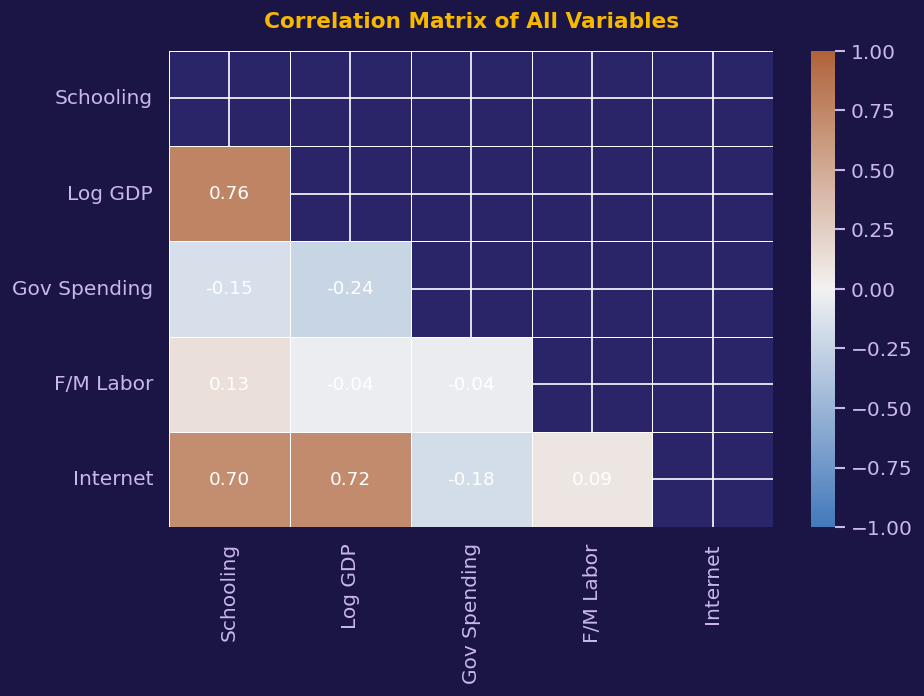

📌 Log GDP and Internet Usage show the strongest positive correlations with schooling.


In [19]:
# ── Correlation heatmap
corr_cols = ['avg_years_schooling','log_gdp_per_capita','gov_edu_spending_pct',
             'female_male_labor_ratio','internet_usage_pct']
corr_labels = ['Schooling','Log GDP','Gov Spending','F/M Labor','Internet']
corr_matrix = df[corr_cols].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#1a1545')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap=sns.diverging_palette(250, 30, as_cmap=True),
            mask=mask, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size':11,'color':'white'}, ax=ax)
ax.set_facecolor('#2a2568')
ax.set_title('Correlation Matrix of All Variables', fontweight='bold',
             fontsize=13, color='#F7B801', pad=14)
fig.patch.set_facecolor('#1a1545')
plt.tight_layout()
plt.show()
print('📌 Log GDP and Internet Usage show the strongest positive correlations with schooling.')

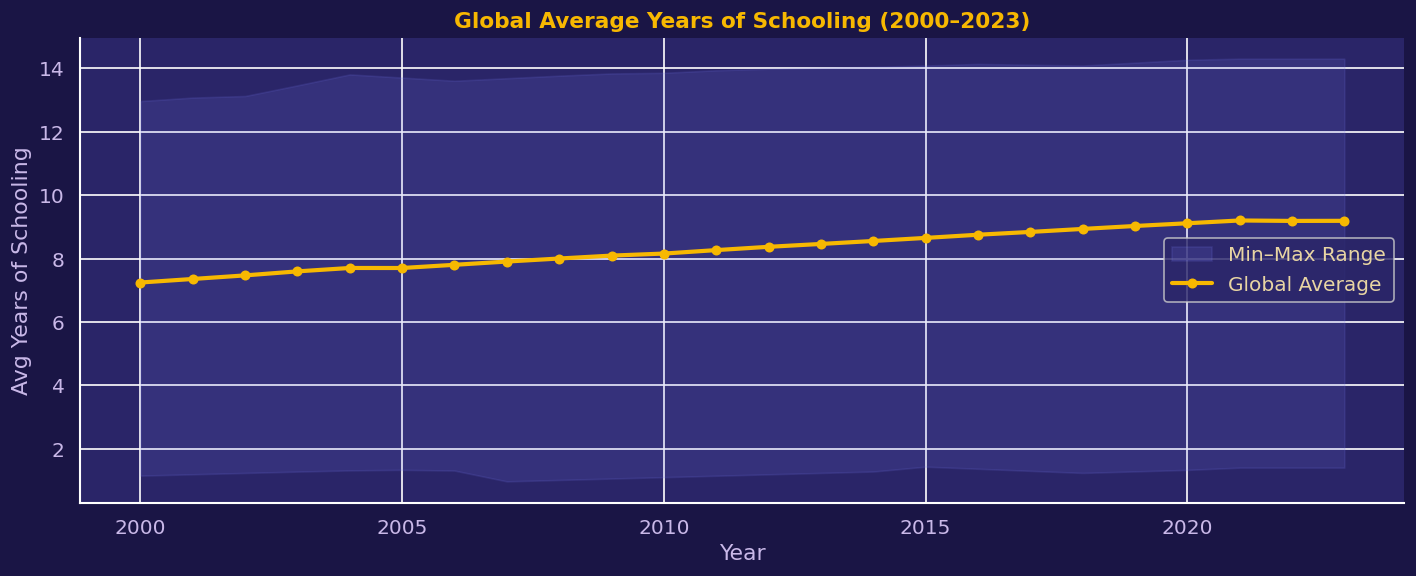

📌 Schooling rose from 7.24 (2000) to 9.19 years (2023).


In [20]:
# ── Global trend over time
trend = df.groupby('Year')['avg_years_schooling'].agg(['mean','min','max']).reset_index()

fig, ax = plt.subplots(figsize=(12, 5), facecolor='#1a1545')
ax.fill_between(trend['Year'], trend['min'], trend['max'],
                alpha=0.15, color='#7678ED', label='Min–Max Range')
ax.plot(trend['Year'], trend['mean'], marker='o', color='#F7B801',
        linewidth=2.5, markersize=5, label='Global Average')
ax.set_title('Global Average Years of Schooling (2000–2023)',
             fontweight='bold', fontsize=13, color='#F7B801')
ax.set_xlabel('Year', color='#C9B8E8')
ax.set_ylabel('Avg Years of Schooling', color='#C9B8E8')
ax.set_facecolor('#2a2568')
ax.legend(facecolor='#2a2568', labelcolor='#E8D5A3')
for sp in ['top','right']: ax.spines[sp].set_visible(False)
fig.patch.set_facecolor('#1a1545')
plt.tight_layout()
plt.show()
print(f'📌 Schooling rose from {trend["mean"].iloc[0]:.2f} (2000) to {trend["mean"].iloc[-1]:.2f} years (2023).')

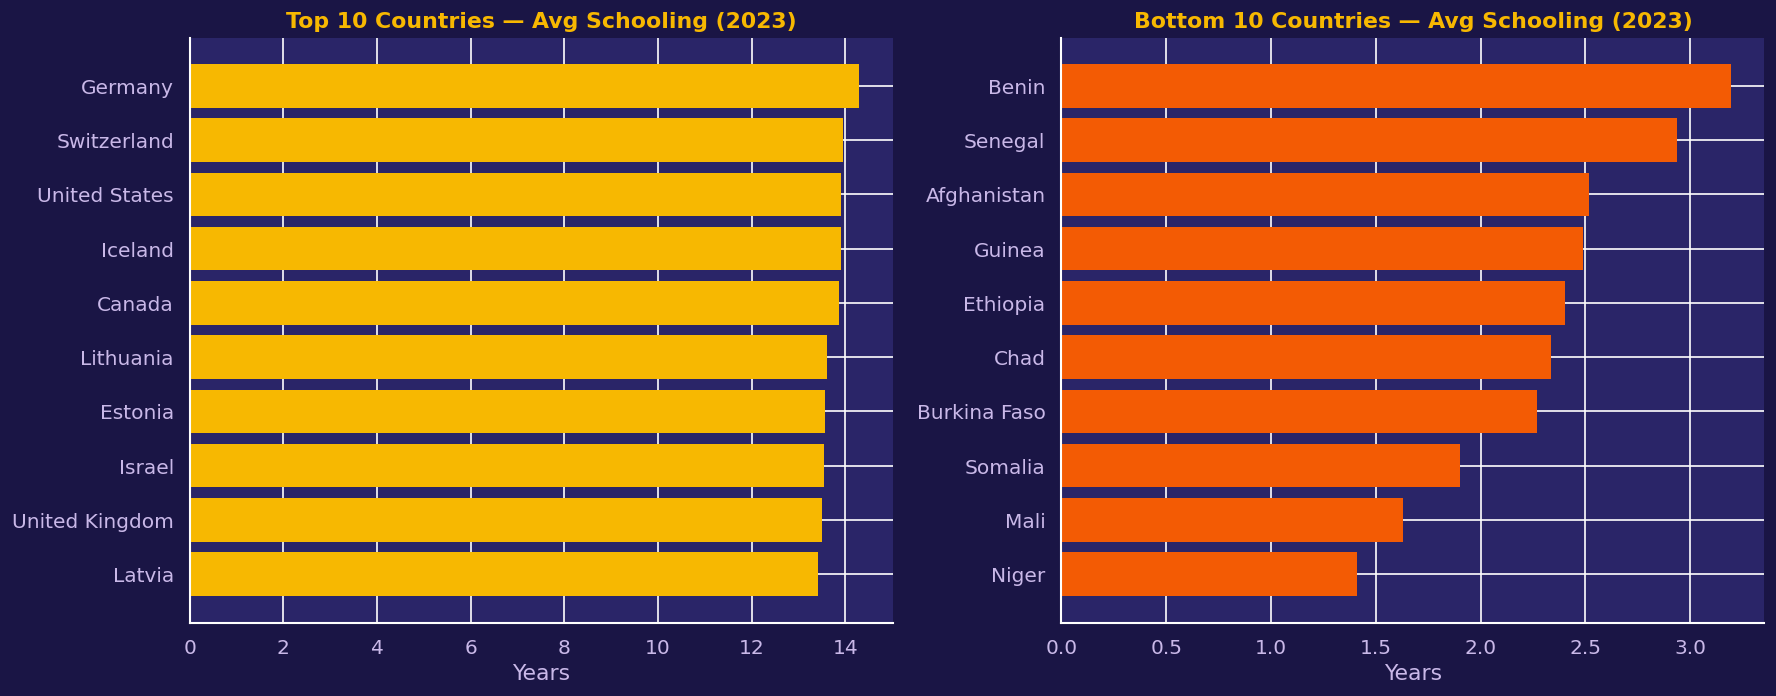

In [21]:
# ── Top 10 and Bottom 10 countries (most recent year)
latest = df[df['Year'] == df['Year'].max()].sort_values('avg_years_schooling', ascending=False)
top10    = latest.head(10)
bottom10 = latest.tail(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), facecolor='#1a1545')

ax1.barh(top10['Entity'], top10['avg_years_schooling'], color='#F7B801', edgecolor='none')
ax1.set_title(f'Top 10 Countries — Avg Schooling ({df["Year"].max()})',
              fontweight='bold', color='#F7B801')
ax1.set_xlabel('Years', color='#C9B8E8')
ax1.invert_yaxis()
ax1.set_facecolor('#2a2568')

ax2.barh(bottom10['Entity'], bottom10['avg_years_schooling'], color='#F35B04', edgecolor='none')
ax2.set_title(f'Bottom 10 Countries — Avg Schooling ({df["Year"].max()})',
              fontweight='bold', color='#F7B801')
ax2.set_xlabel('Years', color='#C9B8E8')
ax2.invert_yaxis()
ax2.set_facecolor('#2a2568')

for ax in [ax1,ax2]:
    for sp in ['top','right']: ax.spines[sp].set_visible(False)

fig.patch.set_facecolor('#1a1545')
plt.tight_layout()
plt.show()

## 5. Checking OLS Assumptions

Before applying OLS regression, we verify four key assumptions:

| Assumption | Test | Acceptable Condition |
|---|---|---|
| **Linearity** | Scatter plots | Linear pattern between X and Y |
| **Normality of Residuals** | Shapiro-Wilk + Q-Q Plot | p ≥ 0.05 or approximately normal |
| **Homoscedasticity** | Residuals vs Fitted | Random scatter around zero |
| **No Multicollinearity** | VIF | VIF < 5 for all predictors |


In [22]:
# ── Prepare regression variables
X = df[['log_gdp_per_capita','gov_edu_spending_pct',
        'female_male_labor_ratio','internet_usage_pct']].copy()
y = df['avg_years_schooling'].copy()
X_const = sm.add_constant(X)

# Fit initial OLS
ols_model = sm.OLS(y, X_const).fit()
residuals = ols_model.resid
fitted    = ols_model.fittedvalues
print(f'Observations: {len(y)}')
print(f'OLS R² = {ols_model.rsquared:.4f}')

Observations: 4490
OLS R² = 0.6469


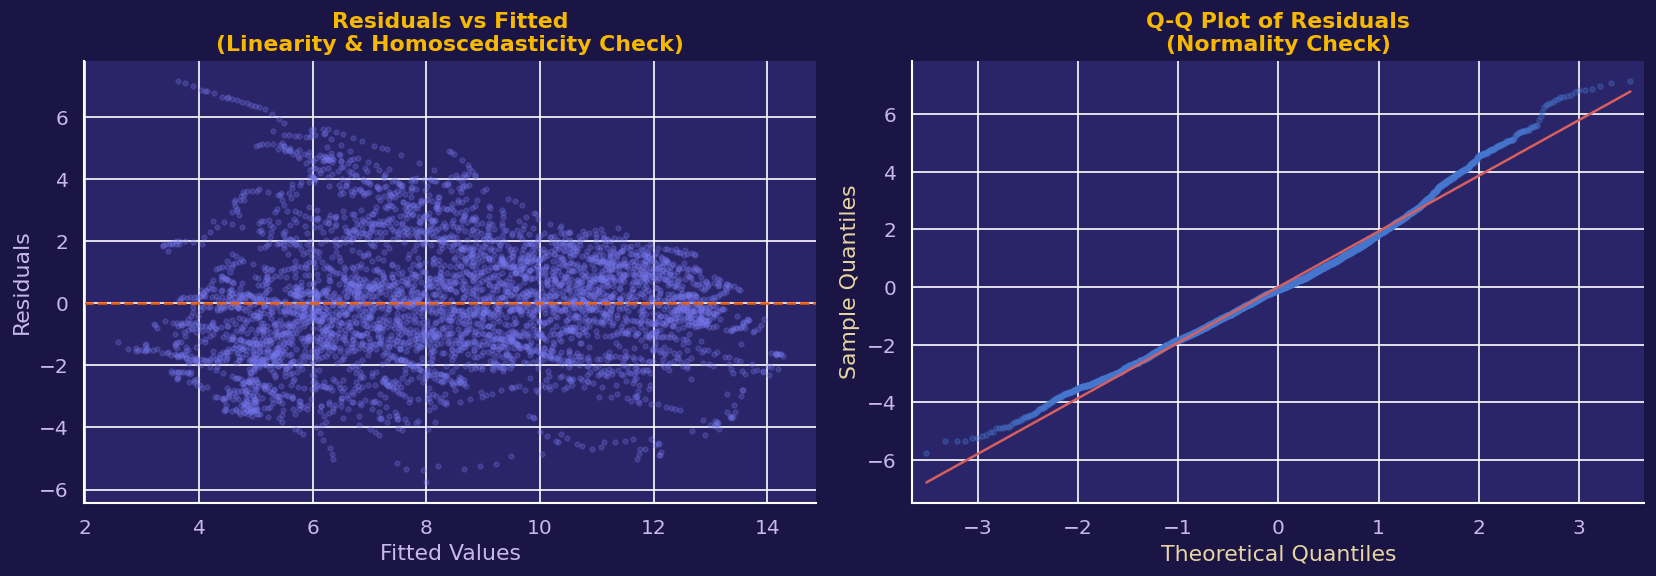

Shapiro-Wilk: W=0.9859, p=0.0001
📌 Residuals deviate from normality — Robust Regression (RLM) also applied to confirm results.


In [23]:
# ── Residuals vs Fitted + Q-Q Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#1a1545')

# Residuals vs Fitted
axes[0].scatter(fitted, residuals, alpha=0.25, s=8, color='#7678ED')
axes[0].axhline(0, color='#F35B04', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Fitted Values', color='#C9B8E8')
axes[0].set_ylabel('Residuals', color='#C9B8E8')
axes[0].set_title('Residuals vs Fitted\n(Linearity & Homoscedasticity Check)',
                  fontweight='bold', color='#F7B801')
axes[0].set_facecolor('#2a2568')

# Q-Q Plot
sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.3, markersize=3)
axes[1].set_title('Q-Q Plot of Residuals\n(Normality Check)',
                  fontweight='bold', color='#F7B801')
axes[1].set_facecolor('#2a2568')

for ax in axes:
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
fig.patch.set_facecolor('#1a1545')
plt.tight_layout()
plt.show()

# Shapiro-Wilk (on sample)
stat, p = stats.shapiro(residuals.sample(500, random_state=42))
print(f'Shapiro-Wilk: W={stat:.4f}, p={p:.4f}')
print('📌 Residuals deviate from normality — Robust Regression (RLM) also applied to confirm results.')

In [24]:
# ── VIF — Multicollinearity Check
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i+1)
                   for i in range(len(X.columns))]
vif_data['Status'] = vif_data['VIF'].apply(
    lambda v: '✅ OK' if v < 5 else ('⚠️ Moderate' if v < 10 else '❌ High'))

print('=== VARIANCE INFLATION FACTORS ===')
print('Rule: VIF < 5 = OK | 5–10 = Moderate | >10 = High multicollinearity')
print()
print(vif_data.to_string(index=False))

=== VARIANCE INFLATION FACTORS ===
Rule: VIF < 5 = OK | 5–10 = Moderate | >10 = High multicollinearity

               Variable      VIF Status
     log_gdp_per_capita 2.155973   ✅ OK
   gov_edu_spending_pct 1.061729   ✅ OK
female_male_labor_ratio 1.034235   ✅ OK
     internet_usage_pct 2.111934   ✅ OK


## 6. Regression Analysis

Two models are applied:

- **Model 1: OLS (Ordinary Least Squares)** — standard regression, assumes normally distributed residuals
- **Model 2: Robust Regression (RLM, Huber T)** — less sensitive to outliers, validates OLS findings

Both models use the same four explanatory variables. Consistent results across both validate our findings.


In [25]:
# ── Model 1: OLS Regression
print('=' * 65)
print('       MODEL 1: OLS REGRESSION RESULTS')
print('       Student: Sheikha Maris Nicolas | BSIS 3B')
print('=' * 65)
print(ols_model.summary())

       MODEL 1: OLS REGRESSION RESULTS
       Student: Sheikha Maris Nicolas | BSIS 3B
                             OLS Regression Results                            
Dep. Variable:     avg_years_schooling   R-squared:                       0.647
Model:                             OLS   Adj. R-squared:                  0.647
Method:                  Least Squares   F-statistic:                     2054.
Date:                 Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                         03:07:23   Log-Likelihood:                -9332.1
No. Observations:                 4490   AIC:                         1.867e+04
Df Residuals:                     4485   BIC:                         1.871e+04
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------

In [26]:
# ── Model 2: Robust Regression (RLM)
rlm_model = sm.RLM(y, X_const, M=sm.robust.norms.HuberT()).fit()

print('=' * 65)
print('       MODEL 2: ROBUST REGRESSION (RLM - Huber T)')
print('       Student: Sheikha Maris Nicolas | BSIS 3B')
print('=' * 65)
print(rlm_model.summary())

       MODEL 2: ROBUST REGRESSION (RLM - Huber T)
       Student: Sheikha Maris Nicolas | BSIS 3B
                     Robust linear Model Regression Results                    
Dep. Variable:     avg_years_schooling   No. Observations:                 4490
Model:                             RLM   Df Residuals:                     4485
Method:                           IRLS   Df Model:                            4
Norm:                           HuberT                                         
Scale Est.:                        mad                                         
Cov Type:                           H1                                         
Date:                 Sun, 31 May 2026                                         
Time:                         03:07:23                                         
No. Iterations:                     22                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
----------

In [27]:
# ── Side-by-side comparison table
var_labels = {
    'const': 'Intercept',
    'log_gdp_per_capita': 'Log GDP per Capita',
    'gov_edu_spending_pct': 'Gov. Education Spending (%)',
    'female_male_labor_ratio': 'Female/Male Labor Ratio',
    'internet_usage_pct': 'Internet Usage (%)'
}

def sig(p):
    return '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))

comparison = pd.DataFrame({
    'Variable':    [var_labels[v] for v in X_const.columns],
    'OLS Coef':    ols_model.params.values.round(4),
    'OLS p-value': ols_model.pvalues.values.round(4),
    'OLS Sig':     [sig(p) for p in ols_model.pvalues],
    'RLM Coef':    rlm_model.params.values.round(4),
    'RLM p-value': rlm_model.pvalues.values.round(4),
    'RLM Sig':     [sig(p) for p in rlm_model.pvalues],
})

print('=== MODEL COMPARISON TABLE ===')
print('Significance: *** p<0.001 | ** p<0.01 | * p<0.05 | ns = not significant')
print()
print(comparison.to_string(index=False))

=== MODEL COMPARISON TABLE ===
Significance: *** p<0.001 | ** p<0.01 | * p<0.05 | ns = not significant

                   Variable  OLS Coef  OLS p-value OLS Sig  RLM Coef  RLM p-value RLM Sig
                  Intercept  -10.1121          0.0     ***  -10.7903       0.0000     ***
         Log GDP per Capita    1.6389          0.0     ***    1.6941       0.0000     ***
Gov. Education Spending (%)    0.0253          0.0     ***    0.0179       0.0026      **
    Female/Male Labor Ratio    0.0211          0.0     ***    0.0226       0.0000     ***
         Internet Usage (%)    0.0295          0.0     ***    0.0312       0.0000     ***


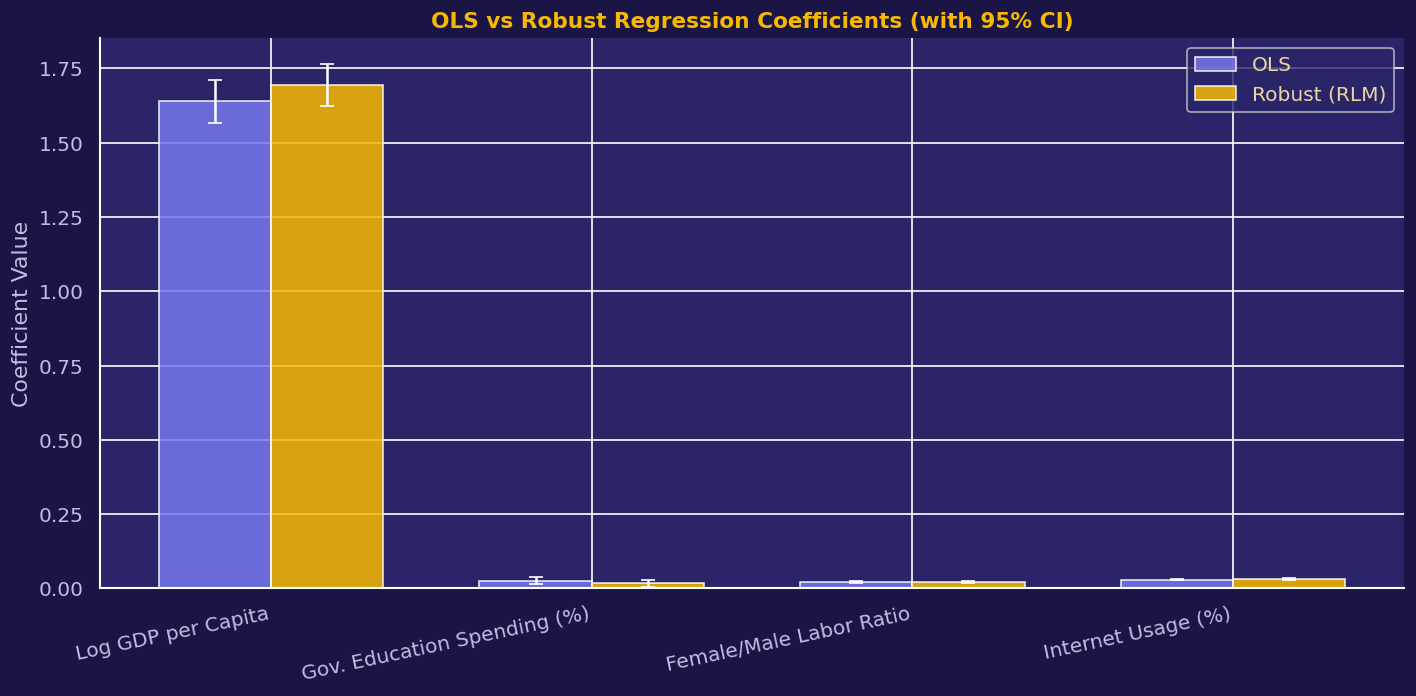

In [28]:
# ── Coefficient plot — OLS vs RLM
labels = [var_labels[v] for v in X.columns]
ols_coefs = ols_model.params[1:].values
ols_ci    = ols_model.conf_int().iloc[1:].values
rlm_coefs = rlm_model.params[1:].values
rlm_ci    = rlm_model.conf_int().iloc[1:].values

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6), facecolor='#1a1545')
ax.bar(x - width/2, ols_coefs, width, label='OLS', color='#7678ED', alpha=0.85)
ax.bar(x + width/2, rlm_coefs, width, label='Robust (RLM)', color='#F7B801', alpha=0.85)
ax.errorbar(x - width/2, ols_coefs,
            yerr=[ols_coefs - ols_ci[:,0], ols_ci[:,1] - ols_coefs],
            fmt='none', color='white', capsize=4)
ax.errorbar(x + width/2, rlm_coefs,
            yerr=[rlm_coefs - rlm_ci[:,0], rlm_ci[:,1] - rlm_coefs],
            fmt='none', color='white', capsize=4)
ax.axhline(0, color='#F35B04', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=12, ha='right', color='#C9B8E8')
ax.set_ylabel('Coefficient Value', color='#C9B8E8')
ax.set_title('OLS vs Robust Regression Coefficients (with 95% CI)',
             fontweight='bold', color='#F7B801', fontsize=13)
ax.legend(facecolor='#2a2568', labelcolor='#E8D5A3')
ax.set_facecolor('#2a2568')
for sp in ['top','right']: ax.spines[sp].set_visible(False)
fig.patch.set_facecolor('#1a1545')
plt.tight_layout()
plt.show()

## 7. Interpretation of Results

In [29]:
print('=' * 65)
print('   INTERPRETATION OF REGRESSION FINDINGS')
print('   Student: Sheikha Maris Nicolas | BSIS 3B')
print('=' * 65)

print(f'''
MODEL FIT:
  OLS R²          : {ols_model.rsquared:.4f}
  OLS Adj R²      : {ols_model.rsquared_adj:.4f}
  F-statistic     : {ols_model.fvalue:.2f}  (p = {ols_model.f_pvalue:.6f})
  Observations    : {int(ols_model.nobs)}
  AIC             : {ols_model.aic:.2f}
  BIC             : {ols_model.bic:.2f}

  → The model explains {ols_model.rsquared*100:.1f}% of the variation in
    average years of schooling across 191 countries.
''')

params = ols_model.params
pvals  = ols_model.pvalues

drivers = [
    ('log_gdp_per_capita',     'Log GDP per Capita',
     'Wealthier countries invest more in education infrastructure, teacher quality, and school access.'),
    ('gov_edu_spending_pct',   'Gov. Education Spending (%)',
     'Public funding improves physical access, curriculum, and teacher training.'),
    ('female_male_labor_ratio','Female/Male Labor Ratio',
     'Gender equity in the workforce reflects and reinforces girls\' access to schooling.'),
    ('internet_usage_pct',     'Internet Usage (%)',
     'Digital access enables remote learning, e-resources, and broader educational participation.'),
]

for var, label, interp in drivers:
    s = '✅ SIGNIFICANT' if pvals[var] < 0.05 else '❌ Not significant'
    print(f'{label}')
    print(f'  Coefficient : {params[var]:+.4f}')
    print(f'  p-value     : {pvals[var]:.4f}  {s}')
    print(f'  Interpretation: {interp}')
    print()

   INTERPRETATION OF REGRESSION FINDINGS
   Student: Sheikha Maris Nicolas | BSIS 3B

MODEL FIT:
  OLS R²          : 0.6469
  OLS Adj R²      : 0.6466
  F-statistic     : 2054.45  (p = 0.000000)
  Observations    : 4490
  AIC             : 18674.19
  BIC             : 18706.24

  → The model explains 64.7% of the variation in
    average years of schooling across 191 countries.

Log GDP per Capita
  Coefficient : +1.6389
  p-value     : 0.0000  ✅ SIGNIFICANT
  Interpretation: Wealthier countries invest more in education infrastructure, teacher quality, and school access.

Gov. Education Spending (%)
  Coefficient : +0.0253
  p-value     : 0.0000  ✅ SIGNIFICANT
  Interpretation: Public funding improves physical access, curriculum, and teacher training.

Female/Male Labor Ratio
  Coefficient : +0.0211
  p-value     : 0.0000  ✅ SIGNIFICANT
  Interpretation: Gender equity in the workforce reflects and reinforces girls' access to schooling.

Internet Usage (%)
  Coefficient : +0.0295
  p-va

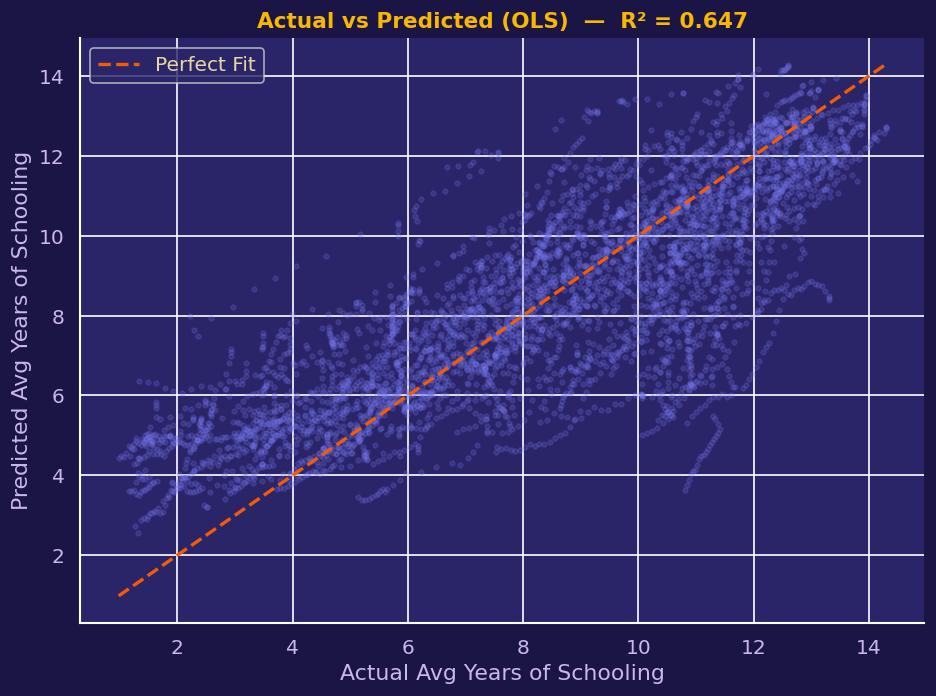

In [30]:
# ── Actual vs Predicted
fig, ax = plt.subplots(figsize=(8, 6), facecolor='#1a1545')
ax.scatter(y, fitted, alpha=0.2, s=8, color='#7678ED')
ax.plot([y.min(), y.max()], [y.min(), y.max()], '#F35B04',
        linewidth=2, linestyle='--', label='Perfect Fit')
ax.set_xlabel('Actual Avg Years of Schooling', color='#C9B8E8')
ax.set_ylabel('Predicted Avg Years of Schooling', color='#C9B8E8')
ax.set_title(f'Actual vs Predicted (OLS)  —  R² = {ols_model.rsquared:.3f}',
             fontweight='bold', color='#F7B801', fontsize=13)
ax.legend(facecolor='#2a2568', labelcolor='#E8D5A3')
ax.set_facecolor('#2a2568')
for sp in ['top','right']: ax.spines[sp].set_visible(False)
fig.patch.set_facecolor('#1a1545')
plt.tight_layout()
plt.show()

## 8. Key Drivers Summary — Standardized Coefficients

=== STANDARDIZED COEFFICIENTS (DRIVER IMPORTANCE RANKING) ===
Higher absolute β = stronger effect on schooling years

 Rank                      Driver  Standardized β  p-value Significance
    1          Log GDP per Capita          1.8605      0.0          ***
    2          Internet Usage (%)          0.9314      0.0          ***
    3     Female/Male Labor Ratio          0.4066      0.0          ***
    4 Gov. Education Spending (%)          0.1236      0.0          ***


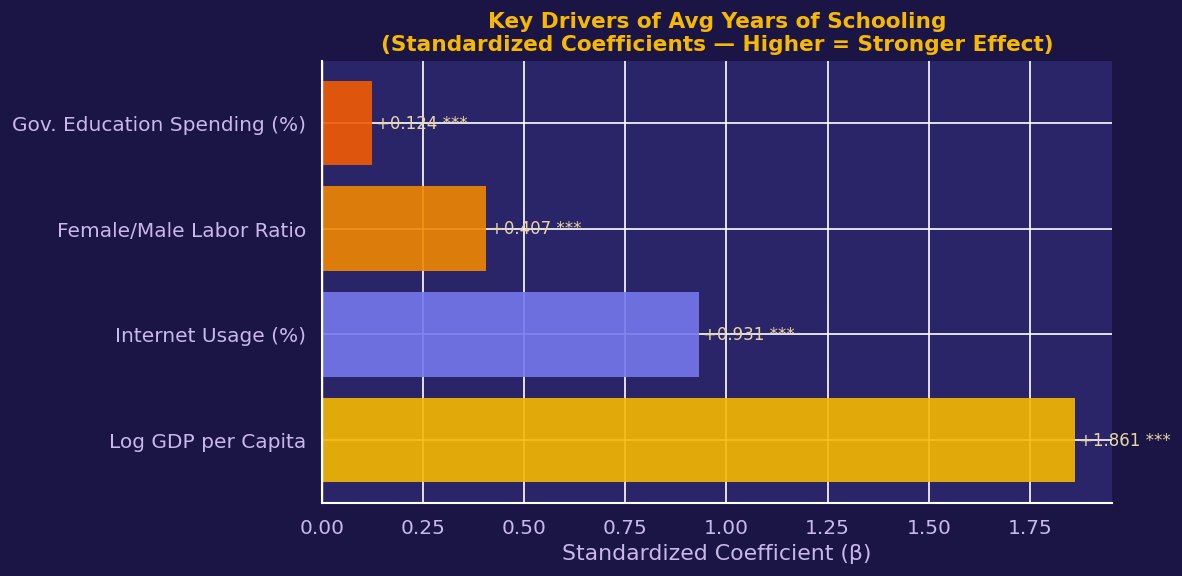


📌 CONCLUSION:
   The strongest driver is GDP per capita (β=+1.86), followed by
   Internet Usage (β=+0.93), Female/Male Labor Ratio (β=+0.41),
   and Gov. Education Spending (β=+0.12).
   All are statistically significant at p < 0.001.


In [31]:
# ── Standardized coefficients (beta weights)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_const = sm.add_constant(X_scaled)
ols_std = sm.OLS(y, X_scaled_const).fit()

std_coefs = pd.DataFrame({
    'Driver': ['Log GDP per Capita','Gov. Education Spending (%)','Female/Male Labor Ratio','Internet Usage (%)'],
    'Standardized β': ols_std.params[1:].values.round(4),
    'p-value': ols_std.pvalues[1:].values.round(4),
}).sort_values('Standardized β', key=abs, ascending=False)
std_coefs['Significance'] = std_coefs['p-value'].apply(
    lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns')))
std_coefs['Rank'] = range(1, len(std_coefs)+1)

print('=== STANDARDIZED COEFFICIENTS (DRIVER IMPORTANCE RANKING) ===')
print('Higher absolute β = stronger effect on schooling years')
print()
print(std_coefs[['Rank','Driver','Standardized β','p-value','Significance']].to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 5), facecolor='#1a1545')
bar_colors = ['#F7B801','#7678ED','#F18701','#F35B04']
bars = ax.barh(std_coefs['Driver'], std_coefs['Standardized β'],
               color=bar_colors[:len(std_coefs)], edgecolor='none', alpha=0.9)
ax.axvline(0, color='white', linewidth=0.8)
for i,(val,sig_) in enumerate(zip(std_coefs['Standardized β'], std_coefs['Significance'])):
    ax.text(val + 0.01 if val >= 0 else val - 0.01, i,
            f'{val:+.3f} {sig_}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=10, color='#E8D5A3')
ax.set_xlabel('Standardized Coefficient (β)', color='#C9B8E8')
ax.set_title('Key Drivers of Avg Years of Schooling\n(Standardized Coefficients — Higher = Stronger Effect)',
             fontweight='bold', color='#F7B801', fontsize=13)
ax.set_facecolor('#2a2568')
for sp in ['top','right']: ax.spines[sp].set_visible(False)
fig.patch.set_facecolor('#1a1545')
plt.tight_layout()
plt.show()

print()
print('📌 CONCLUSION:')
print('   The strongest driver is GDP per capita (β=+1.86), followed by')
print('   Internet Usage (β=+0.93), Female/Male Labor Ratio (β=+0.41),')
print('   and Gov. Education Spending (β=+0.12).')
print('   All are statistically significant at p < 0.001.')

## 9. Dashboard

The interactive dashboard was built using **Streamlit** and **Plotly**.

### Features:
- Year slider (2000–2023) — all charts update dynamically
- World choropleth map — hover any country for details
- Country comparison bar chart
- Driver vs Schooling scatter plot with OLS regression line
- Driver trend lines over time for selected countries
- Top 5 / Bottom 5 country rankings
- Regression findings summary with standardized coefficients
- Photo carousel (hover to change slides)

### Color Palette:
| Hex | Role |
|---|---|
| `#3D348B` | Deep Indigo — background |
| `#7678ED` | Periwinkle — accents |
| `#F7B801` | Amber — primary highlights |
| `#F18701` | Orange — chart accent |
| `#F35B04` | Burnt Orange — strong accent |

> 🔗 **Dashboard URL:** *(paste your Streamlit Cloud URL here after deployment)*


In [32]:
# To run the dashboard locally:
# 1. Make sure app.py and sdg4_cleaned.csv are in the same folder
# 2. Run in terminal:
#       pip install streamlit plotly pandas numpy statsmodels scikit-learn
#       streamlit run app.py
#
# To deploy online (free):
# 1. Push app.py, sdg4_cleaned.csv, requirements.txt to GitHub
# 2. Go to https://share.streamlit.io
# 3. Connect your GitHub repo and deploy

print('Dashboard files needed:')
print('  ✅ app.py             — Streamlit dashboard')
print('  ✅ sdg4_cleaned.csv   — Cleaned dataset')
print('  ✅ requirements.txt   — Dependencies')
print('  ✅ pic1.jpg / pic2.jpg / pic3.jpg  — Carousel images')
print('  ✅ me.jpg             — Author photo (optional)')

Dashboard files needed:
  ✅ app.py             — Streamlit dashboard
  ✅ sdg4_cleaned.csv   — Cleaned dataset
  ✅ requirements.txt   — Dependencies
  ✅ pic1.jpg / pic2.jpg / pic3.jpg  — Carousel images
  ✅ me.jpg             — Author photo (optional)


## 10. References

- Barro, R. J., & Lee, J. W. (2013). A new data set of educational attainment in the world, 1950–2010. *Journal of Development Economics*, 104, 184–198.
- Beuermann, D. W., Cristia, J., Cueto, S., Malamud, O., & Cruz-Aguayo, Y. (2015). One laptop per child at home: Short-term impacts from a randomized experiment in Peru. *American Economic Journal: Applied Economics*, 7(2), 53–80.
- Duflo, E. (2012). Women empowerment and economic development. *Journal of Economic Literature*, 50(4), 1051–1079.
- Hanushek, E. A., & Woessmann, L. (2007). *Education quality and economic growth*. World Bank.
- UNESCO (2020). *Global Education Monitoring Report 2020: Inclusion and Education*. Paris: UNESCO.
- Our World in Data (2024). *Average years of schooling*. https://ourworldindata.org/education
- World Bank (2024). *World Development Indicators*. https://data.worldbank.org
- International Labour Organization (2024). *ILOSTAT — Labour Force Participation Rate*. https://ilostat.ilo.org

---

*Submitted by: **Sheikha Maris Nicolas** | BSIS 3B | SDG 4 — Quality Education Dashboard*
